# RaF Zeeman Slower diagnostic — `zeeman_slower_2.ipynb`

Goals — given X²Σ ↔ A²Π½ in 226RaF (with 19F I=½):

1. Build the full transition map: dipole MEs $d_{ij,p}(B)$ in the field-dressed basis (Wigner–Eckart with lab spherical $p\in\{-1,0,+1\}\equiv\{\sigma^-,\pi,\sigma^+\}$).
2. For every (i,j,p): output transition frequency $\nu_{ij}(B)$, slope $d\nu_{ij}/dB$, and $|d_{ij,p}|^2$ normalized to the max coupling at the lowest sampled B (~ stretched-state ME for case-(b) ground; A^2Pi_{1/2} mixing makes the equality approximate).
3. Diagnostic plots A–E.
4. Rate-equation force calculation (Yan & Liang, *PRA* **100**, 053402 (2019); Tarbutt, *J. Mod. Opt.* **65**, 648 (2018)).

**Conventions**
- MHz, Gauss, V/cm. $\mu_B = 1.399624494$ MHz/Gauss.
- Lab polarization $p$: $\sigma^+\!\leftrightarrow\!p=+1$ (Δm=+1), $\sigma^-\!\leftrightarrow\!p=-1$, $\pi\!\leftrightarrow\!p=0$.
- Molecule-frame component $q\in(-1,+1)$ for the perpendicular X²Σ→A²Π electronic transition.
- Excited subspace for the rate-eq force calc: A²Π½ J'=½, single Λ-doublet parity (`+` by default → 4 sublevels for I=½). Ground: X²Σ N=1 (12 sublevels for I=½).

**Knobs / caveats**
- $\Gamma/2\pi = 4.6$ MHz ($\tau\approx 35$ ns) — replaceable below; see `RaF_A2Pi_gamma_estimate.md` in this dir.
- $\lambda = 753$ nm from the A-state `Origin` parameter ($T_e + A_{SO}\approx 13{,}284$ cm⁻¹).
- TDMs are squared and normalized by the max over $(i,j,p)$ at the lowest sampled B (~ case-(b) stretched ME for the perpendicular transition; approximate since A^2Pi_{1/2} is case-(a)/aBJ).


In [1]:
from config_path import add_to_sys_path
add_to_sys_path()

Added /Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code to sys.path


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba
from matplotlib.cm import ScalarMappable
from copy import deepcopy

from Energy_Levels import MoleculeLevels, Calculate_TDM_evecs

# Physical constants in (MHz, Gauss, m, s)
h_J     = 6.62607015e-34          # J s
hbar_J  = 1.054571817e-34         # J s
c_ms    = 2.998e8                 # m/s
mu_B    = 1.399624494             # MHz/Gauss (matches molecule_parameters)
amu     = 1.66053906660e-27       # kg

# RaF
mass_RaF = (226 + 19) * amu       # kg, 226Ra19F
lam_XA   = 753e-9                 # m   (RaF X-A v=0->v'=0)
k_XA     = 2*np.pi / lam_XA       # rad/m
v_recoil = hbar_J * k_XA / mass_RaF        # m/s per scattered photon

# Excited-state lifetime knob (angular freq, MHz)
Gamma_2pi_MHz = 4.6
GAMMA_MHz     = 2*np.pi * Gamma_2pi_MHz    # used in rate-eq linewidth: 1 + 4 Δ^2 / Γ^2
print(f'v_recoil = {v_recoil*1e3:.3f} mm/s,   Γ/2π = {Gamma_2pi_MHz:.2f} MHz')

v_recoil = 2.163 mm/s,   Γ/2π = 4.60 MHz


## Step 1 — build state objects and run ZeemanMap

In [3]:
N_g = [1]
N_e = [1,2]

g = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='X', vib_state=0,
    N_list=N_g, fermion_or_boson='boson',
    M_sublevels='all', I_nuclei=[0, 1/2], isotope=226,
    round=8, P_values=[1/2],
)
e = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='A', vib_state=0,
    N_list=N_e, fermion_or_boson='boson',
    M_sublevels='all', I_nuclei=[0, 1/2], isotope=226,
    round=8, P_values=[1/2],
)
g.eigensystem(0, 1e-3); e.eigensystem(0, 1e-3)
print('g size =', g.size, '  e size =', e.size)

g size = 12   e size = 48


In [4]:
Bz = np.linspace(1e-3, 1000.0, 101)   # Gauss
g.ZeemanMap(Bz, plot=False)
e.ZeemanMap(Bz, plot=False)
print('ZeemanMap shapes:', g.evals_B.shape, e.evals_B.shape)

ZeemanMap shapes: (101, 12) (101, 48)


## Step 2 — full transition map: $d_{ij,p}(B)$, $\nu_{ij}(B)$, slopes, normalization

For each $B$, compute the per-polarization TDM matrix $T_p[B,j,i] = \langle e_j | T^p_q | g_i\rangle$ summed over molecule-frame $q\in\{-1,+1\}$ (perpendicular electronic transition). Frequencies $\nu_{ij}(B) = E^{(e)}_j(B) - E^{(g)}_i(B)$ in MHz; slopes $d\nu_{ij}/dB$ via central differences.

In [5]:
import io as _io, contextlib as _ctx

def _hoist_to_aBJ(state):
    """Convert state.evecs_B (all B-points) to aBJ once. Suppresses
    convert_evecs's verbose=True default.  Returns (evecs_aBJ, q_numbers_aBJ)."""
    if 'a' in state.hunds_case:
        return state.evecs_B, state.q_numbers
    with _ctx.redirect_stdout(_io.StringIO()):
        probe = state.convert_evecs('aBJ', evecs=state.evecs_B[0], Normalize=False)
        out = np.empty((len(state.Bz),) + probe.shape, dtype=probe.dtype)
        out[0] = probe
        for i in range(1, len(state.Bz)):
            out[i] = state.convert_evecs('aBJ', evecs=state.evecs_B[i], Normalize=False)
    return out, state.alt_q_numbers['aBJ']


def build_transition_map(g, e, ground_query=None, excited_query=None,
                          parity_g=None, parity_e=None,
                          q_electronic=(-1, +1)):
    '''Return dict of arrays for every (i, j, p) over Bz.

    Shapes: TDM[N_B, 3, n_e, n_g], dE[N_B, n_e, n_g], slope[N_B, n_e, n_g].
    p index: [0,1,2] -> [sigma-, pi, sigma+]  (lab spherical p = -1, 0, +1).
    Case conversion is hoisted outside the (B, p) loop; the inner work is a
    pure batched matmul against TDM_p_builders[iso_state].
    '''
    Bz = g.Bz
    assert np.array_equal(Bz, e.Bz)
    N_B = len(Bz)

    g_idx = (np.arange(g.size) if ground_query  is None
             else g.select_q(ground_query,  parity=parity_g))
    e_idx = (np.arange(e.size) if excited_query is None
             else e.select_q(excited_query, parity=parity_e))

    G_a, G_qn = _hoist_to_aBJ(g)
    E_a, E_qn = _hoist_to_aBJ(e)

    p_lab = (-1, 0, +1)
    TDM_full = np.zeros((N_B, 3, e.size, g.size), dtype=complex)
    for ip, p in enumerate(p_lab):
        TDM_matrix = e.library.TDM_p_builders[e.iso_state](
            p, list(q_electronic), G_qn, E_qn)
        TDM_full[:, ip] = E_a @ TDM_matrix @ G_a.transpose(0, 2, 1)

    TDM = TDM_full[:, :, e_idx[:, None], g_idx[None, :]]   # (N_B, 3, n_e, n_g)
    dE  = e.evals_B[:, e_idx, None] - g.evals_B[:, None, g_idx]  # MHz
    slope = np.gradient(dE, Bz, axis=0)                          # MHz / G

    return {
        'Bz': Bz, 'g_idx': g_idx, 'e_idx': e_idx,
        'TDM': TDM, 'TDM_full': TDM_full,
        'dE': dE, 'slope': slope,
        'p_lab': p_lab, 'q_electronic': tuple(q_electronic),
    }

# ALL of N=1 ground x A J'=1/2 (both parities of the Lambda-doublet).
TM_full = build_transition_map(g, e,
                               ground_query={'N': [1]},
                               excited_query={'J': 0.5})
print({k: (v.shape if hasattr(v,'shape') else type(v).__name__) for k,v in TM_full.items()})

{'Bz': (101,), 'g_idx': (12,), 'e_idx': (8,), 'TDM': (101, 3, 8, 12), 'TDM_full': (101, 3, 48, 12), 'dE': (101, 8, 12), 'slope': (101, 8, 12), 'p_lab': 'tuple', 'q_electronic': 'tuple'}


In [6]:
# Reference normalization: max coupling at lowest sampled B (~ stretched-state ME
# for case-(b) ground; A^2Pi_{1/2} is case-(a)/aBJ so the equality is approximate).
TDM2     = np.abs(TM_full['TDM'])**2
TDM2_ref = float(TDM2[0].max())
TDM2_norm = TDM2 / TDM2_ref                          # (N_B, 3, n_e, n_g)
TM_full['TDM2_norm'] = TDM2_norm
TM_full['TDM2_ref']  = TDM2_ref
print(f'TDM^2 reference (max coupling at lowest sampled B) = {TDM2_ref:.5e} (MHz/(V/cm))^2')
print('TDM2_norm range:', TDM2_norm.min(), TDM2_norm.max())

TDM^2 reference (max coupling at lowest sampled B) = 2.44841e-01 (MHz/(V/cm))^2
TDM2_norm range: 0.0 2.519138437962997


### Ground-state character labels at every $B$

`g.q_numbers` is the case-(b) coupled basis (good QN at low $B$: $K,N,J,F,M$). At high $B$ we want the dominant $m_S$ from the *decoupled* basis. We compute both.

In [7]:
def ground_character(g):
    """Return dict with arrays shape (N_B, g.size) of dominant QN labels.

    decoupled keys for I_list=[0,1/2]: ['K','N','M_N','M_S','M_I','M_F'].
    """
    Bz = g.Bz; N_B = len(Bz)
    qN  = g.q_numbers
    J_dom = np.empty((N_B, g.size))
    M_dom = np.empty((N_B, g.size))
    Ndom  = np.empty((N_B, g.size))
    for ib in range(N_B):
        evecs = g.evecs_B[ib]
        for k in range(g.size):
            j = int(np.argmax(evecs[k]**2))
            J_dom[ib, k] = qN['J'][j]
            M_dom[ib, k] = qN['M'][j]
            Ndom [ib, k] = qN['N'][j]
    dec_qn = g.alt_q_numbers['decoupled']
    mS_key = 'M_S' if 'M_S' in dec_qn else ('m_S' if 'm_S' in dec_qn else None)
    mS_dom = np.empty((N_B, g.size))
    if mS_key is None:
        mS_dom[:] = np.nan
    else:
        for ib in range(N_B):
            evecs_dec = g.convert_evecs('decoupled', evecs=g.evecs_B[ib],
                                        Normalize=False, verbose=False)
            for k in range(g.size):
                j = int(np.argmax(evecs_dec[k]**2))
                mS_dom[ib, k] = dec_qn[mS_key][j]
    return {'J': J_dom, 'M': M_dom, 'N': Ndom, 'mS': mS_dom, 'mS_key': mS_key}

g_char_full = ground_character(g)
print('decoupled keys:', list(g.alt_q_numbers['decoupled']))
print('mS_key used:', g_char_full['mS_key'])
print('J_dom unique  (B~0):', np.unique(g_char_full['J'][0]))
print('mS unique (B small):', np.unique(g_char_full['mS'][0]))
print('mS unique (B max  ):', np.unique(g_char_full['mS'][-1]))


decoupled keys: ['K', 'N', 'M_N', 'M_S', 'M_I', 'M_F']
mS_key used: M_S
J_dom unique  (B~0): [0.5 1.5]
mS unique (B small): [-0.5  0.5]
mS unique (B max  ): [-0.5  0.5]


### Subset utility — pick the slowing-relevant ground manifold

For Plot A–E we want X²Σ N=1 (12 sublevels with I=½) → A²Π½ J'=½ +parity (4 sublevels). The transition map produced above includes more than this; subset for clarity.

In [8]:
def subset_TM(TM_full, g, e, g_keep_query, e_keep_query, parity_g=None, parity_e=None):
    '''Restrict an existing transition map to a subset of g and e indices.'''
    g_keep = g.select_q(g_keep_query, parity=parity_g)
    e_keep = e.select_q(e_keep_query, parity=parity_e)
    full_g = list(TM_full['g_idx'])
    full_e = list(TM_full['e_idx'])
    g_pos  = [full_g.index(int(gi)) for gi in g_keep if int(gi) in full_g]
    e_pos  = [full_e.index(int(ej)) for ej in e_keep if int(ej) in full_e]
    g_pos  = np.asarray(g_pos); e_pos = np.asarray(e_pos)
    out = {
        'Bz': TM_full['Bz'],
        'g_idx': TM_full['g_idx'][g_pos],
        'e_idx': TM_full['e_idx'][e_pos],
        'TDM':       TM_full['TDM']      [:, :, e_pos[:,None], g_pos[None,:]],
        'TDM_full':  TM_full['TDM_full'],
        'dE':        TM_full['dE']       [:,    e_pos[:,None], g_pos[None,:]],
        'slope':     TM_full['slope']    [:,    e_pos[:,None], g_pos[None,:]],
        'TDM2_norm': TM_full['TDM2_norm'][:, :, e_pos[:,None], g_pos[None,:]],
        'TDM2_ref':  TM_full['TDM2_ref'],
        'p_lab':     TM_full['p_lab'],
        'q_electronic': TM_full['q_electronic'],
    }
    return out, g_pos, e_pos

TM, g_pos, e_pos = subset_TM(TM_full, g, e,
                             g_keep_query={'N': [1]}, e_keep_query={'J': 0.5},
                             parity_e='+')
n_g_sub = len(TM['g_idx']); n_e_sub = len(TM['e_idx'])
print(f'Subset: {n_g_sub} ground sublevels (X N=1), {n_e_sub} excited (A Jp=1/2 +parity)')

Subset: 12 ground sublevels (X N=1), 4 excited (A Jp=1/2 +parity)


## Step 3 — diagnostic plots

### Plot A — transition frequencies vs $B$

Three panels for $\sigma^+, \sigma^-, \pi$. Color: dominant ground-state character (J at low $B$, $m_S$ at high $B$). Linewidth ∝ $|d_{ij,p}|^2_{\rm norm}$.

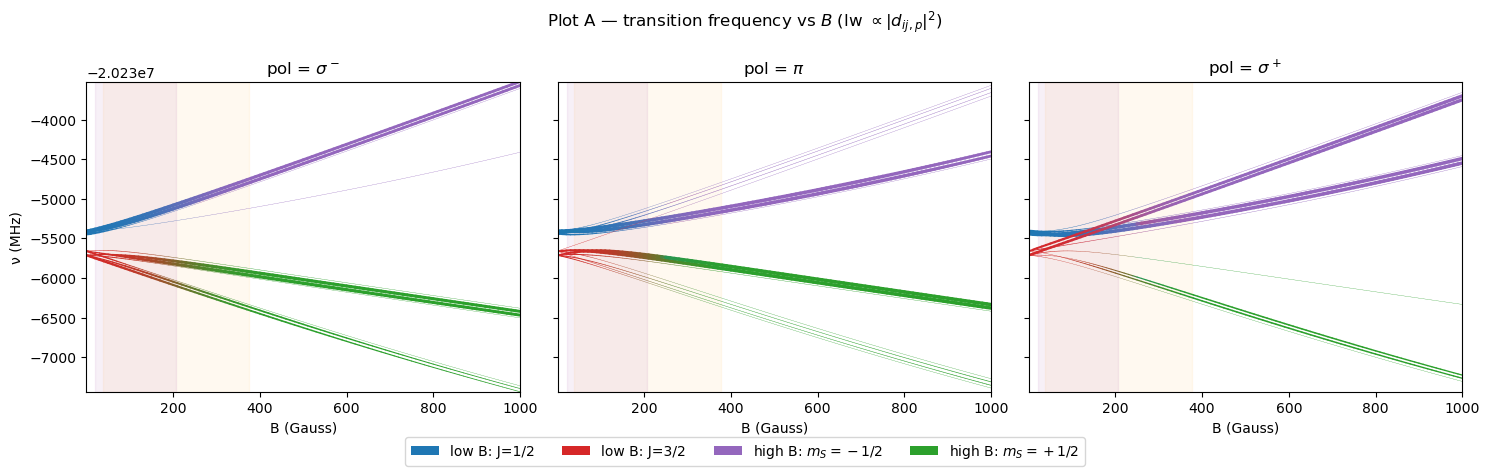

In [9]:
import molecule_parameters as _mp
_X0 = _mp.molecules['RaF']['boson']['X0']
_B_SR_default = (0.3 * _X0['Gamma_SR'] / mu_B, 3.0 * _X0['Gamma_SR'] / mu_B)
_B_HF_default = (0.3 * _X0['bF']       / mu_B, 3.0 * _X0['bF']       / mu_B)

def plot_A_transition_frequencies(TM, g_char, g_pos,
                                  B_SR_PB=_B_SR_default, B_HF_PB=_B_HF_default,
                                  lw_min=0.2, lw_max=2.5,
                                  fig_kwargs=None):
    Bz   = TM['Bz']
    dE   = TM['dE']
    TDM2 = TM['TDM2_norm']
    p_lab = TM['p_lab']
    n_B, _, n_e, n_g = TDM2.shape

    # color: J at low B blends to mS at high B as logistic in B around B_SR_PB[1]
    B_PB_mid = 0.5*(B_SR_PB[0] + B_SR_PB[1])
    w_high   = 1 / (1 + np.exp(-(Bz - B_PB_mid)/(0.25*B_PB_mid)))   # 0->low, 1->high
    # discrete colormap for J ∈ {1/2, 3/2}, mS ∈ {-1/2, +1/2}
    J_vals = np.unique(g_char['J'][0, g_pos])
    cmap_low  = {0.5: '#1f77b4', 1.5: '#d62728'}
    cmap_high = {-0.5: '#9467bd', 0.5: '#2ca02c'}

    fig_kwargs = fig_kwargs or dict(figsize=(15, 4.5))
    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, **fig_kwargs)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    for ip, ax in enumerate(axes):
        for je in range(n_e):
            for ig in range(n_g):
                lw = lw_min + (lw_max - lw_min) * np.clip(TDM2[:, ip, je, ig], 0, 1)
                if lw.max() < 1.05*lw_min:
                    continue
                # build segment colors: blend low (J) and high (mS)
                Jdom  = g_char['J'] [:, g_pos[ig]]
                mSdom = g_char['mS'][:, g_pos[ig]]
                # snap to nearest known categories
                colors_low  = np.array([to_rgba(cmap_low.get (round(2*j)/2, '#888'))  for j  in Jdom])
                colors_high = np.array([to_rgba(cmap_high.get(round(2*m)/2, '#888')) for m in mSdom])
                W = w_high[:, None]
                colors = (1-W)*colors_low + W*colors_high

                # plot as colored line segments via LineCollection
                from matplotlib.collections import LineCollection
                pts  = np.column_stack([Bz, dE[:, je, ig]])
                segs = np.stack([pts[:-1], pts[1:]], axis=1)
                seg_col = 0.5*(colors[:-1] + colors[1:])
                seg_lw  = 0.5*(lw   [:-1] + lw   [1:])
                lc = LineCollection(segs, colors=seg_col, linewidths=seg_lw, capstyle='round')
                ax.add_collection(lc)
        ax.axvspan(*B_SR_PB, alpha=0.06, color='orange', label='SR Paschen-Back' if ip==0 else None)
        ax.axvspan(*B_HF_PB, alpha=0.06, color='purple',  label='HF Paschen-Back (est.)' if ip==0 else None)
        ax.set_xlabel('B (Gauss)')
        if ip == 0: ax.set_ylabel('ν (MHz)')
        ax.set_title(f'pol = {pol_names[ip]}')

    ax.set_xlim(Bz.min(), Bz.max())
    ax.set_ylim(np.nanmin(dE), np.nanmax(dE))

    # legend (color encoding)
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=cmap_low [0.5], label='low B: J=1/2'),
               Patch(facecolor=cmap_low [1.5], label='low B: J=3/2'),
               Patch(facecolor=cmap_high[-0.5],label='high B: $m_S=-1/2$'),
               Patch(facecolor=cmap_high[ 0.5],label='high B: $m_S=+1/2$')]
    fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Plot A — transition frequency vs $B$ (lw $\\propto |d_{ij,p}|^2$)')
    fig.tight_layout()
    return fig, axes

figA, _ = plot_A_transition_frequencies(TM, g_char_full, g_pos)
plt.show()

### Plot B — slope $d\nu_{ij}/dB$ vs $B$, with Doppler-trackable bands

Cluster `(j,i,p)` transitions that share BOTH `dν/dB` (within `tol`) AND mean
frequency (within `freq_tol_MHz`) over the B-window where both are bright. The
joint criterion is what "Doppler-trackable" actually requires — slope agreement
alone is necessary but not sufficient (two ~zero-offset transitions at very
different frequencies need different lasers, even if their B-tracking is
identical). Zero-slope transitions are flagged as untrackable for any laser.

22 total clusters; 4 with at least 3 members (candidate Doppler-trackable bands)


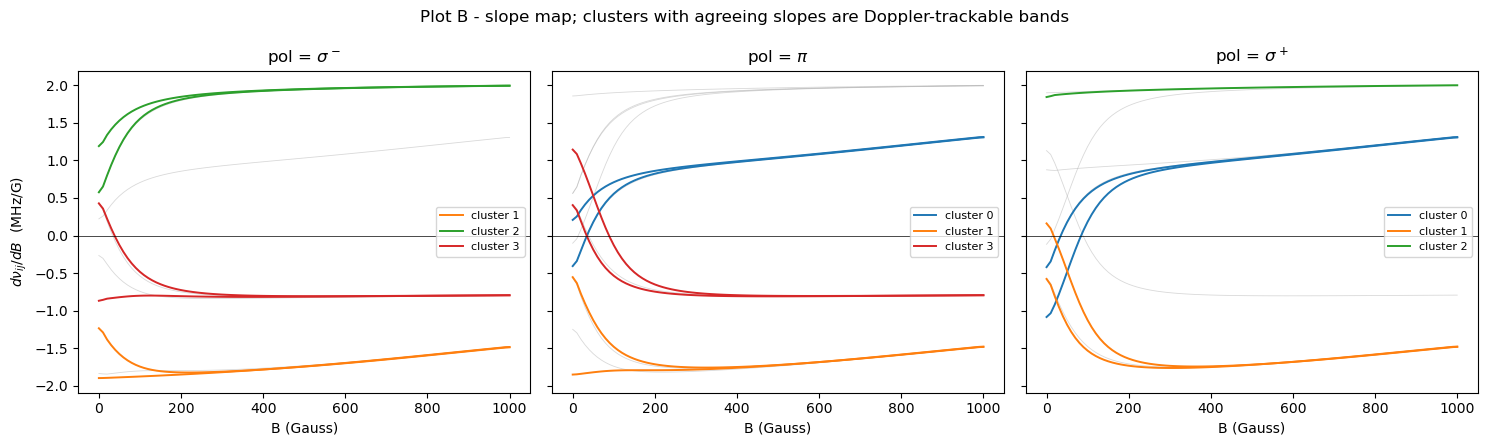

In [10]:
def find_doppler_trackable_bands(TM, tol=0.2, min_TDM2=0.05,
                                   min_overlap=0.4, freq_tol_MHz=200.):
    """Cluster (j,i,p) transitions sharing slope-vs-B AND mean frequency.

    Two transitions cluster only if (a) median relative slope difference is
    within `tol` over at least `min_overlap` of the bright-overlap B-window,
    AND (b) their mean frequency over that window is within `freq_tol_MHz`.
    Set freq_tol_MHz=np.inf to recover the slope-only behavior.
    """
    sl   = TM["slope"]                     # (N_B, n_e, n_g)
    TDM2 = TM["TDM2_norm"]                 # (N_B, 3, n_e, n_g)
    N_B, _, n_e, n_g = TDM2.shape
    bright = (TDM2.max(axis=(0,1)) > min_TDM2)   # (n_e, n_g)
    j_e, j_g = np.where(bright)
    keys = []; curves = []; weights = []
    for je, ig in zip(j_e, j_g):
        for ip in range(3):
            w = TDM2[:, ip, je, ig]
            if w.max() < min_TDM2: continue
            keys.append((int(je), int(ig), int(ip)))
            curves.append(sl[:, je, ig])
            weights.append(w)
    curves  = np.array(curves)
    weights = np.array(weights)

    clusters = []
    assigned = np.zeros(len(curves), dtype=bool)
    for i in range(len(curves)):
        if assigned[i]: continue
        members = [i]; assigned[i] = True
        for j in range(i+1, len(curves)):
            if assigned[j]: continue
            mask = (weights[i] > min_TDM2) & (weights[j] > min_TDM2)
            if mask.sum() < min_overlap * N_B: continue
            denom = np.maximum(np.abs(curves[i][mask]), np.abs(curves[j][mask]))
            denom = np.where(denom < 1e-9, 1e-9, denom)
            rel   = np.abs(curves[i][mask] - curves[j][mask]) / denom
            if np.median(rel) > tol: continue
            # frequency-coincidence test
            je_i, ig_i, _ = keys[i]; je_j, ig_j, _ = keys[j]
            df = np.abs(TM["dE"][mask, je_i, ig_i].mean()
                      - TM["dE"][mask, je_j, ig_j].mean())
            if df > freq_tol_MHz: continue
            members.append(j); assigned[j] = True
        clusters.append([keys[m] for m in members])
    return clusters, keys

def plot_B_slopes(TM, g_char, g_pos, clusters,
                  zero_slope_thresh=0.005, min_TDM2=0.02, fig_kwargs=None):
    Bz   = TM["Bz"]; sl = TM["slope"]; TDM2 = TM["TDM2_norm"]
    N_B, _, n_e, n_g = TDM2.shape
    pol_names = [r"$\sigma^-$", r"$\pi$", r"$\sigma^+$"]
    fig_kwargs = fig_kwargs or dict(figsize=(15, 4.5))
    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, **fig_kwargs)

    big_clusters = [c for c in clusters if len(c) >= 3]
    cmap = plt.get_cmap("tab10")

    for ip, ax in enumerate(axes):
        # background grey lines for all visible transitions
        for je in range(n_e):
            for ig in range(n_g):
                w = TDM2[:, ip, je, ig]
                if w.max() < min_TDM2: continue
                ax.plot(Bz, sl[:, je, ig], color="0.7", lw=0.6, alpha=0.5)

        # cluster overlays
        for ic, cl in enumerate(big_clusters):
            label_drawn = False
            for (je, ig, ipp) in cl:
                if ipp != ip: continue
                lbl = f"cluster {ic}" if not label_drawn else None
                ax.plot(Bz, sl[:, je, ig], color=cmap(ic % 10), lw=1.4, label=lbl)
                label_drawn = True

        # zero-slope flag
        zs_drawn = False
        for je in range(n_e):
            for ig in range(n_g):
                if TDM2[:, ip, je, ig].max() < min_TDM2: continue
                if np.abs(sl[:, je, ig]).max() < zero_slope_thresh:
                    lbl = "zero-slope (untrackable)" if not zs_drawn else None
                    ax.plot(Bz, sl[:, je, ig], color="red", lw=1.6, alpha=0.7, label=lbl)
                    zs_drawn = True

        ax.axhline(0, color="k", lw=0.5)
        ax.set_xlabel("B (Gauss)"); ax.set_title(f"pol = {pol_names[ip]}")
        if ip == 0: ax.set_ylabel(r"$d\nu_{ij}/dB$  (MHz/G)")
        if big_clusters or zs_drawn:
            ax.legend(fontsize=8, loc="best")

    fig.suptitle("Plot B - slope map; clusters with agreeing slopes are Doppler-trackable bands")
    fig.tight_layout()
    return fig, axes

clusters_all, keys_all = find_doppler_trackable_bands(TM, tol=0.2, min_TDM2=0.05)
n_big = sum(1 for c in clusters_all if len(c) >= 3)
print(f"{len(clusters_all)} total clusters; {n_big} with at least 3 members (candidate Doppler-trackable bands)")
figB, _ = plot_B_slopes(TM, g_char_full, g_pos, clusters_all)
plt.show()

### Plot C — required $B(z)$ per transition

For $v(z) = \sqrt{v_i^2 - 2\eta a_{\max} z}$ with $\eta=0.5$, $v_i=150$ m/s, $v_f=10$ m/s, $L = (v_i^2 - v_f^2)/(2\eta a_{\max})$.

Resonance condition for transition $\nu_{ij}(B) - kv = \nu_L$, with $\nu_L$ fixed at $z=0$ by choosing $B_0$. Linearize: $B(z) = B_0 + k\,(v(z) - v_i) / (d\nu_{ij}/dB)$ — valid where slope changes slowly with $B$.

In [11]:
def slowing_profile(v_i=150., v_f=10., eta=0.5, a_max=None, n_z=400):
    '''v(z) for the user's profile; return (z, v).'''
    if a_max is None:
        # Use a_max consistent with ~1/3 of max scattering force
        # F_max = ħk Γ/2 → a_max = ħk Γ /(2 m). We compute it externally.
        raise ValueError('Provide a_max in m/s^2.')
    L = (v_i**2 - v_f**2) / (2*eta*a_max)
    z = np.linspace(0, L, n_z)
    v = np.sqrt(np.maximum(v_i**2 - 2*eta*a_max*z, v_f**2))
    return z, v, L

def required_Bz(TM, B_0_idx, je, ig, ip, k=k_XA, v_i=150., v_f=10., eta=0.5, a_max=None, n_z=400):
    '''Return (z, v(z), B(z)) for one transition (je, ig, ip), linearized in slope.'''
    Bz = TM['Bz']
    sl = TM['slope'][B_0_idx, je, ig]      # MHz/G; convert to Hz/G
    sl_HzG = sl * 1e6
    z, v, L = slowing_profile(v_i, v_f, eta, a_max, n_z)
    # Δν_required(z) = (v(z) - v_i) * k * c / (2π) ? Careful units:
    # k v has units rad/s; ν is Hz; so Δν = (k v) / (2π).
    dnu_req_Hz = (v - v_i) * k / (2*np.pi)        # Hz
    dnu_req_MHz = dnu_req_Hz * 1e-6
    if abs(sl) < 1e-6:
        return z, v, np.full_like(z, np.nan)
    B0 = Bz[B_0_idx]
    Bz_z = B0 + dnu_req_MHz / sl                  # Gauss
    return z, v, Bz_z

# Compute a_max from F_max = ħk Γ_eff / 2 with Γ_eff ~ Γ * (n_excited / (n_g + n_excited)) saturation cap.
# Use the ideal cycling cap a_idx = ħk Γ / (2m) for an order estimate.
a_max_est = hbar_J * k_XA * (2*np.pi*Gamma_2pi_MHz*1e6) / (2 * mass_RaF)
print(f'Estimate of max deceleration  a_max ≈ {a_max_est:.3e} m/s^2')

Estimate of max deceleration  a_max ≈ 3.126e+04 m/s^2


B_0 = 420.0 G  (index 42)


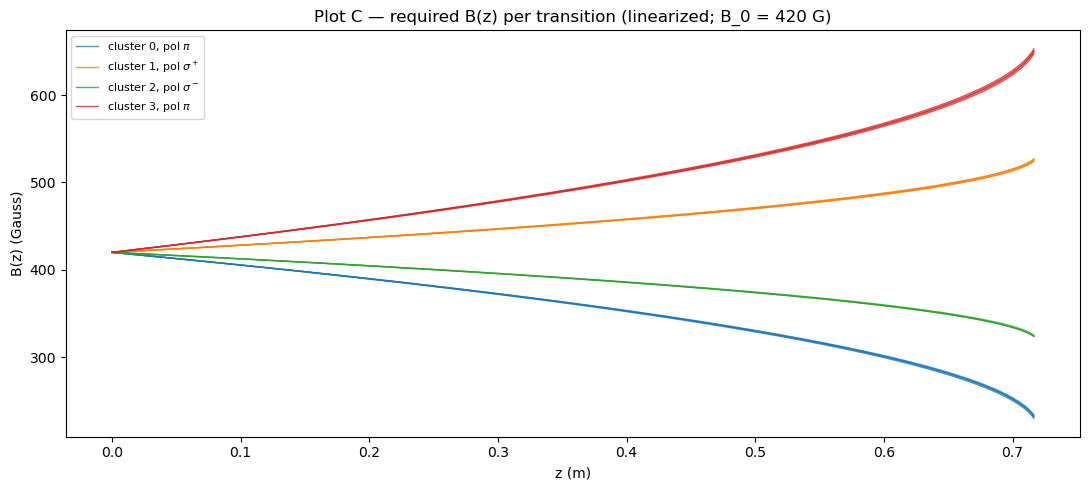

In [12]:
# Plot C: overlay B(z) for the 'best' transitions (those in the largest cluster)
def plot_C_required_Bz(TM, g_char, g_pos, clusters,
                       v_i=150., v_f=10., eta=0.5, a_max=None,
                       B_0=None, min_TDM2=0.05, fig_kwargs=None):
    Bz = TM['Bz']
    if B_0 is None:
        # default to mid-grid (representative slope)
        B_0_idx = len(Bz) // 2
    else:
        B_0_idx = int(np.argmin(np.abs(Bz - B_0)))
    print(f'B_0 = {Bz[B_0_idx]:.1f} G  (index {B_0_idx})')

    fig_kwargs = fig_kwargs or dict(figsize=(11, 5))
    fig, ax = plt.subplots(**fig_kwargs)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    cmap = plt.get_cmap('tab10')
    plotted = []
    big_clusters = [c for c in clusters if len(c) >= 3]
    if not big_clusters:
        big_clusters = clusters[:1]  # show at least the largest if no big ones
    for ic, cl in enumerate(big_clusters):
        for (je, ig, ip) in cl:
            if TM['TDM2_norm'][B_0_idx, ip, je, ig] < min_TDM2: continue
            z, v, Bz_z = required_Bz(TM, B_0_idx, je, ig, ip,
                                     v_i=v_i, v_f=v_f, eta=eta, a_max=a_max)
            ax.plot(z, Bz_z, color=cmap(ic % 10), alpha=0.8, lw=1.0,
                    label=f'cluster {ic}, pol {pol_names[ip]}' if (je,ig,ip)==cl[0] else None)
            plotted.append((ic, je, ig, ip))
    ax.set_xlabel('z (m)'); ax.set_ylabel('B(z) (Gauss)')
    ax.set_title(f'Plot C — required B(z) per transition (linearized; B_0 = {Bz[B_0_idx]:.0f} G)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax, plotted

figC, axC, _ = plot_C_required_Bz(TM, g_char_full, g_pos, clusters_all,
                                  a_max=a_max_est, B_0=420.)
plt.show()

### Plot D — branching-ratio map

For each excited level $j$ and **photon** polarization $p$, the fractional spontaneous-emission rate to each ground sublevel: $\mathrm{BR}_{ji,p} = |\langle g_i|T^p|e_j\rangle|^2 / \sum_{p'} \sum_{i'\in\rm all\,grounds} |\langle g_{i'}|T^{p'}|e_j\rangle|^2$. We split into:

* "diagonal" — $\sum_{p}\mathrm{BR}_{ji,p}$ summed over the *selected* (slowing) ground-state subspace,
* "leakage" — $1 - \mathrm{diagonal}$, ie decays to states outside the subspace (need repumps or remixing).

In [13]:
def compute_branching(TM_full, e_pos, g_pos):
    '''Return BR (N_B, n_e_sub, n_g_sub, 3) and leakage (N_B, n_e_sub).'''
    TDM_full = TM_full['TDM_full']                # (N_B, 3, n_e_full, n_g_full)
    e_idx_full = TM_full['e_idx']                  # array of full-state indices in 'e' object
    g_idx_full = TM_full['g_idx']
    e_idx_sub  = e_idx_full[e_pos]                 # (n_e_sub,)
    g_idx_sub  = g_idx_full[g_pos]                 # (n_g_sub,)
    # |TDM|^2 from this excited subset to ALL grounds (in g object):
    num_per_p_all = np.abs(TDM_full[:, :, e_idx_sub, :])**2     # (N_B, 3, n_e_sub, n_g_full)
    denom         = num_per_p_all.sum(axis=(1,3))               # (N_B, n_e_sub)
    BR_all_per_p  = num_per_p_all / np.where(denom[:, None, :, None] > 0,
                                             denom[:, None, :, None], 1.0)
    BR_sub_per_p  = BR_all_per_p[:, :, :, g_idx_sub]            # (N_B, 3, n_e_sub, n_g_sub)
    BR_sub_total  = BR_sub_per_p.sum(axis=1)                    # (N_B, n_e_sub, n_g_sub)
    diag_total    = BR_sub_total.sum(axis=2)                    # (N_B, n_e_sub)
    leakage       = 1.0 - diag_total
    return BR_sub_per_p, BR_sub_total, leakage

BR_per_p, BR_total, leakage = compute_branching(TM_full, e_pos, g_pos)
print('BR_per_p shape:', BR_per_p.shape, 'leakage shape:', leakage.shape)
print('mean leakage (N=1 cycle, all B):', leakage.mean())

BR_per_p shape: (101, 3, 4, 12) leakage shape: (101, 4)
mean leakage (N=1 cycle, all B): 1.2915960930045139e-17


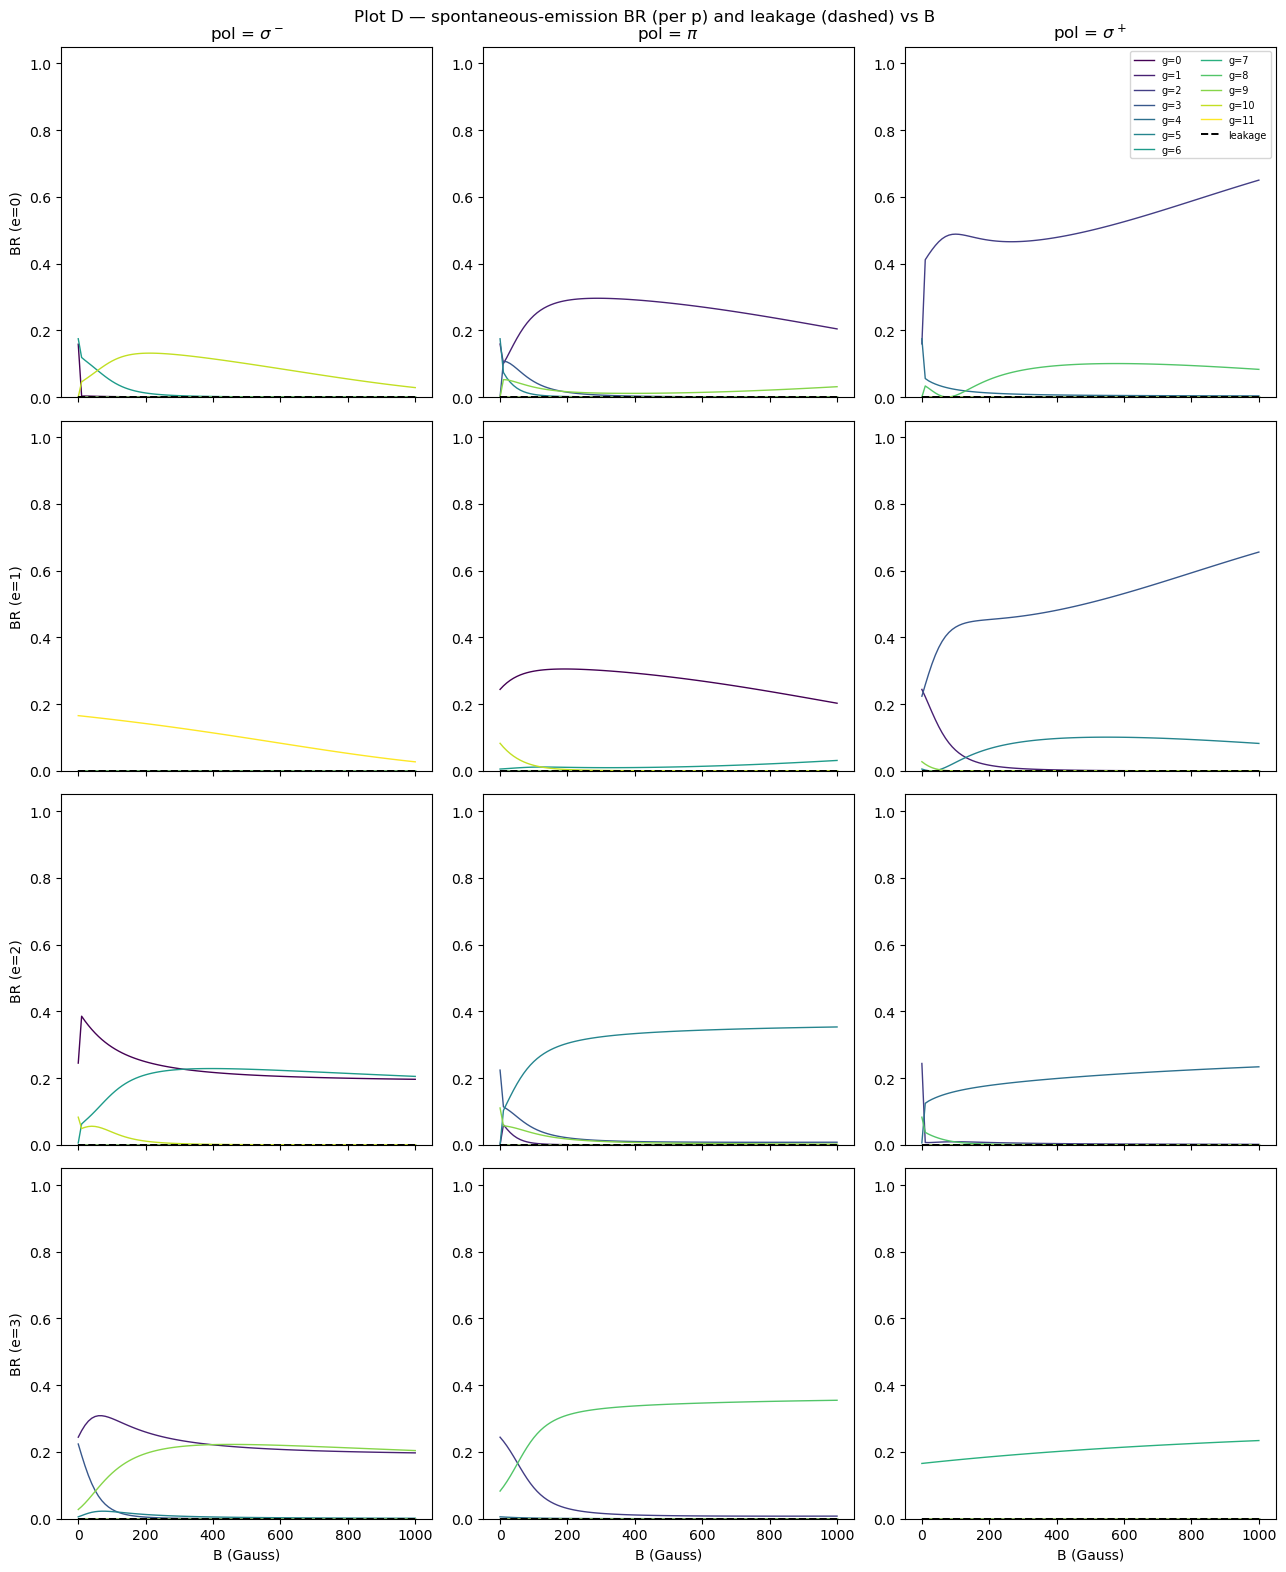

In [14]:
def plot_D_branching(TM, BR_per_p, BR_total, leakage, fig_kwargs=None):
    Bz = TM['Bz']
    n_B, _, n_e, n_g = BR_per_p.shape
    fig_kwargs = fig_kwargs or dict(figsize=(13, 4*n_e))
    fig, axes = plt.subplots(n_e, 3, sharex=True, **fig_kwargs)
    if n_e == 1: axes = axes.reshape(1, 3)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    cmap = plt.get_cmap('viridis', n_g)
    for je in range(n_e):
        for ip in range(3):
            ax = axes[je, ip]
            for ig in range(n_g):
                ax.plot(Bz, BR_per_p[:, ip, je, ig], color=cmap(ig), lw=1.0,
                        label=f'g={ig}')
            ax.plot(Bz, leakage[:, je], color='k', lw=1.4, ls='--', label='leakage')
            ax.set_ylim(0, 1.05)
            if je == 0: ax.set_title(f'pol = {pol_names[ip]}')
            if ip == 0: ax.set_ylabel(f'BR (e={je})')
            if je == n_e-1: ax.set_xlabel('B (Gauss)')
            if (je, ip) == (0, 2): ax.legend(fontsize=7, ncol=2, loc='upper right')
    fig.suptitle('Plot D — spontaneous-emission BR (per p) and leakage (dashed) vs B')
    fig.tight_layout()
    return fig, axes

figD, _ = plot_D_branching(TM, BR_per_p, BR_total, leakage)
plt.show()

### Plot E — dark-state count vs $B$ per polarization

A ground sublevel $i$ is "dark" to polarization $p$ at field $B$ if $\sum_j |d_{ji,p}(B)|^2_{\rm norm} < 0.01$.

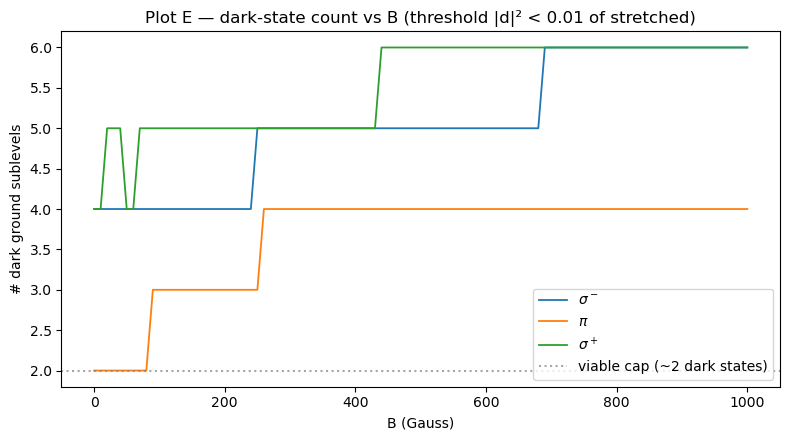

In [15]:
def dark_state_count(TM, threshold=0.01):
    TDM2 = TM['TDM2_norm']                      # (N_B, 3, n_e, n_g)
    sum_over_e = TDM2.sum(axis=2)               # (N_B, 3, n_g)
    is_dark    = sum_over_e < threshold         # (N_B, 3, n_g)
    counts     = is_dark.sum(axis=2)            # (N_B, 3)
    return counts, is_dark

def plot_E_dark_states(TM, threshold=0.01, fig_kwargs=None):
    counts, _ = dark_state_count(TM, threshold)
    Bz = TM['Bz']
    fig_kwargs = fig_kwargs or dict(figsize=(8, 4.5))
    fig, ax = plt.subplots(**fig_kwargs)
    pol_names = [r'$\sigma^-$', r'$\pi$', r'$\sigma^+$']
    for ip in range(3):
        ax.plot(Bz, counts[:, ip], lw=1.3, label=pol_names[ip])
    ax.axhline(2, color='gray', ls=':', alpha=0.7, label='viable cap (~2 dark states)')
    ax.set_xlabel('B (Gauss)'); ax.set_ylabel('# dark ground sublevels')
    ax.set_title(f'Plot E — dark-state count vs B (threshold |d|² < {threshold} of stretched)')
    ax.legend()
    fig.tight_layout()
    return fig, ax

figE, _ = plot_E_dark_states(TM, threshold=0.01)
plt.show()

## Step 4 — rate-equation force calculation

Following Tarbutt (2018) and Yan & Liang (2019). Steady-state rate equations for $n_g + n_e$ levels:

$$ R_{lu,p}(B,v) = \frac{\Gamma}{2}\,\frac{s_p\, b_{lu,p}(B)}{1 + 4\Delta_{lu,p}^2/\Gamma^2 + 2 s_p\, b_{lu,p}(B)} $$

with $b_{lu,p}(B) = |d_{lu,p}(B)|^2_{\rm norm}$, $s_p$ = on-resonance saturation per polarization, $\Delta_{lu,p}(B,v) = (\omega_L + \delta_p) - \omega_{lu}(B) - kv$.

Steady-state populations satisfy $M \mathbf{N} = 0$ with $\sum N = 1$. The total force is

$$ F = \sum_{l,u,p} \hbar k_p \, R_{lu,p}(B,v)\,(N_l - N_u). $$

For the slowing (counter-propagating beam at $-\hat z$) we take $k_p \rightarrow -k$ for all polarizations (single beam direction, polarization is the spin angular momentum carried).

We restrict to the closed cycle: $X^2\Sigma\,N{=}1 \to A^2\Pi_{1/2}\,J'{=}1/2,\,+\text{parity}$. Leakage to other ground states is *separately* logged from Plot D — assumed zero in the rate equations (perfect repumping or chosen subspace closure).

**Caveat: laser auto-retunes per query.** `steady_state_rate_eq` re-anchors
`omega_L_MHz` at the queried `B` so the reference transition is on resonance.
F(v, B) plots therefore represent the optimum-tuned-laser envelope at each B,
NOT a fixed-frequency laser sweep.


In [16]:
def steady_state_rate_eq(TM, Bz_query, v, polarization='sigma+', s_per_p=1.0,
                          detuning_MHz=0.0, ref_transition=None,
                          Gamma_2pi_MHz=Gamma_2pi_MHz, remix=1e-3,
                          verbose_leakage=True, leakage_thresh=0.01):
    """Solve dN/dt = 0 for one (B, v) and return populations + force.

    Args
    ----
    TM            : transition map dict (subset to slowing manifold)
    Bz_query      : scalar B (Gauss) — uses nearest grid point
    v             : scalar molecule velocity (m/s) along beam axis
    polarization  : 'sigma+', 'sigma-', 'pi', or dict {p: s_factor}
    s_per_p       : on-resonance saturation for the chosen polarization
    detuning_MHz  : laser detuning δ (MHz) from the chosen reference transition
    ref_transition: (je, ig). None → strongest at B=0 in active polarization
    Gamma_2pi_MHz : excited-state linewidth (Γ/2π) in MHz
    remix         : small dimensionless saturation added isotropically to ALL p
                    (mocks polarization remixing / angled bias field). Setting
                    remix=0 will fail when dark states exist.

    Returns dict (N, Nl, Nu, F, scattering_rate, ...).
    """
    Bz = TM['Bz']
    iB = int(np.argmin(np.abs(Bz - Bz_query)))
    TDM2 = TM['TDM2_norm']        # (N_B, 3, n_e, n_g)
    dE   = TM['dE']               # MHz   (e - g)
    n_B, _, n_e, n_g = TDM2.shape

    # polarization mapping
    s_vec = np.zeros(3)
    if isinstance(polarization, dict):
        for pp, sval in polarization.items():
            ip = {-1:0, 0:1, +1:2}[int(pp)]
            s_vec[ip] = float(sval) * s_per_p
    else:
        ip = {'sigma-':0, 'pi':1, 'sigma+':2}[polarization]
        s_vec[ip] = s_per_p
    # add isotropic remixing saturation
    s_vec_eff = s_vec + remix
    s_vec_force = s_vec.copy()    # for force calc, only "real" laser drives momentum

    # reference transition
    if ref_transition is None:
        active_ip = int(np.argmax(s_vec))
        je0, ig0 = np.unravel_index(np.argmax(TDM2[0, active_ip]), (n_e, n_g))
    else:
        je0, ig0 = ref_transition
    omega_L_MHz = dE[iB, je0, ig0] + detuning_MHz   # laser anchored at this B

    omega_lu = dE[iB]                                          # (n_e, n_g) MHz
    Doppler  = k_XA * v / (2*np.pi) * 1e-6                     # MHz
    Delta    = omega_L_MHz - omega_lu - Doppler                # (n_e, n_g) MHz

    Gamma_lin = Gamma_2pi_MHz                                  # MHz
    R_p_eff   = np.zeros((3, n_e, n_g))                        # rate per pol (rad/s -> 1/s)
    R_p_force = np.zeros((3, n_e, n_g))                        # force-contributing rate
    for ip in range(3):
        b = TDM2[iB, ip]
        sat_eff   = s_vec_eff[ip]   * b
        sat_force = s_vec_force[ip] * b
        denom = 1.0 + (2.0*Delta/Gamma_lin)**2 + 2.0*sat_eff
        prefac = (2*np.pi*Gamma_2pi_MHz*1e6) / 2.0
        R_p_eff[ip]   = prefac * sat_eff   / denom
        R_p_force[ip] = prefac * sat_force / denom
    R = R_p_eff.sum(axis=0)                                    # (n_e, n_g)

    # spontaneous-emission BR within subset (closed-cycle assumption)
    weights_e2g = TDM2[iB].sum(axis=0)                          # (n_e, n_g) — subset, normalized
    Z_subset_norm = weights_e2g.sum(axis=1)                     # (n_e,) — for BR closure
    BR_e2g = weights_e2g / np.where(Z_subset_norm[:, None] > 0, Z_subset_norm[:, None], 1.0)
    # Leakage diagnostic — must use raw |TDM_full|^2 for both num and denom
    # (mixing TDM2_norm subset with raw full is a unit error and was previously dead).
    e_idx_full = TM['e_idx']; g_idx_sub = TM['g_idx']
    weights_full_raw = (np.abs(TM['TDM_full'][iB])**2).sum(axis=0)               # (n_e_full, n_g_full)
    Z_full_raw   = weights_full_raw[e_idx_full, :].sum(axis=1)                   # (n_e_sub,)
    Z_subset_raw = weights_full_raw[e_idx_full[:, None], g_idx_sub[None, :]].sum(axis=1)
    leakage_at_B = 1.0 - Z_subset_raw / np.where(Z_full_raw > 0, Z_full_raw, 1.0)
    if verbose_leakage and leakage_at_B.max() > leakage_thresh:
        print(f"⚠ closed-cycle assumption: subset leakage = "
              f"{100*leakage_at_B.max():.2f}% at B = {Bz[iB]:.1f} G")
    Gamma_total_s = 2*np.pi*Gamma_2pi_MHz*1e6                   # 1/s

    # build linear rate matrix M (N_g + N_e × same)
    nT = n_g + n_e
    M = np.zeros((nT, nT))
    for l in range(n_g):
        for u in range(n_e):
            r  = R[u, l]
            br = BR_e2g[u, l] * Gamma_total_s
            M[l, l]         -= r
            M[l, n_g + u]   += r + br
    for u in range(n_e):
        for l in range(n_g):
            r = R[u, l]
            M[n_g + u, l]         += r
            M[n_g + u, n_g + u]   -= r
        M[n_g + u, n_g + u] -= Gamma_total_s

    # impose Σ N = 1, solve via lstsq (handles ill-conditioning)
    Mr = np.vstack([M, np.ones((1, nT))])
    rhs = np.concatenate([np.zeros(nT), [1.0]])
    N, *_ = np.linalg.lstsq(Mr, rhs, rcond=None)
    N = np.clip(N, 0, None)
    N = N / N.sum()

    Nl = N[:n_g]; Nu = N[n_g:]
    pop_diff = Nl[None, :] - Nu[:, None]                        # (n_e, n_g)
    scattering_rate = (R_p_force * pop_diff[None, :, :]).sum()  # 1/s
    F = -hbar_J * k_XA * scattering_rate                        # N

    return {
        'N': N, 'Nl': Nl, 'Nu': Nu,
        'R_per_pol': R_p_force, 'BR_e2g': BR_e2g,
        'F': F, 'scattering_rate': scattering_rate,
        'Bz_used': Bz[iB], 'omega_L_MHz': omega_L_MHz,
        'iB': iB, 'ref': (je0, ig0),
        'leakage': leakage_at_B,
    }

# Smoke test
res = steady_state_rate_eq(TM, 200., 0., polarization='sigma+', s_per_p=2.0, remix=1e-3)
print(f"  R_total = {res['scattering_rate']:.3e} /s,   F = {res['F']:.3e} N")
print(f"  ground populations: {np.round(res['Nl'], 3)}")
print(f"  excited populations: {np.round(res['Nu'], 3)}, sum_N = {res['N'].sum():.6f}")


  R_total = 2.828e-01 /s,   F = -2.488e-28 N
  ground populations: [0.003 0.    0.    0.    0.    0.    0.032 0.    0.    0.001 0.035 0.929]
  excited populations: [0. 0. 0. 0.], sum_N = 1.000000


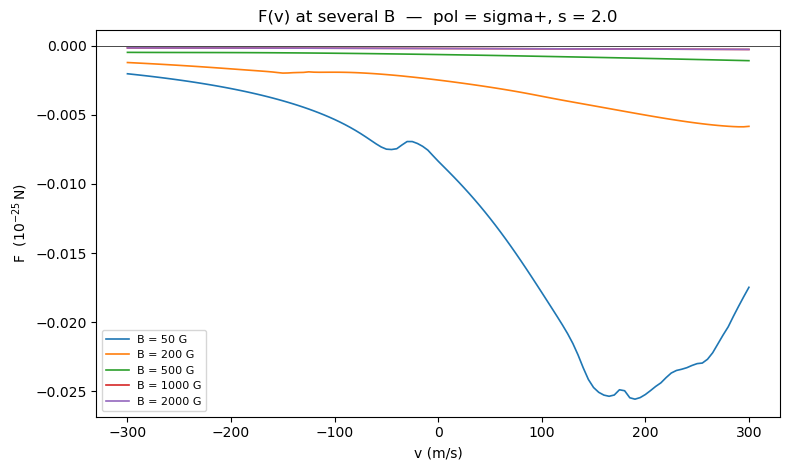

In [17]:
# Plot F(v) at several B
def plot_force_vs_v(TM, B_list_G, v_min=-300, v_max=300, n_v=121,
                    polarization='sigma+', s_per_p=2.0, detuning_MHz=0.0):
    v_arr = np.linspace(v_min, v_max, n_v)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    for B in B_list_G:
        F_arr = np.array([steady_state_rate_eq(
            TM, B, v, polarization=polarization, s_per_p=s_per_p,
            detuning_MHz=detuning_MHz)['F'] for v in v_arr])
        ax.plot(v_arr, F_arr*1e25, lw=1.2, label=f'B = {B:.0f} G')
    ax.set_xlabel('v (m/s)'); ax.set_ylabel(r'F  $(10^{-25}\,$N)')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'F(v) at several B  —  pol = {polarization}, s = {s_per_p}')
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax, v_arr

figF1, _, v_arr = plot_force_vs_v(TM, [50, 200, 500, 1000, 2000], polarization='sigma+', s_per_p=2.0)
plt.show()

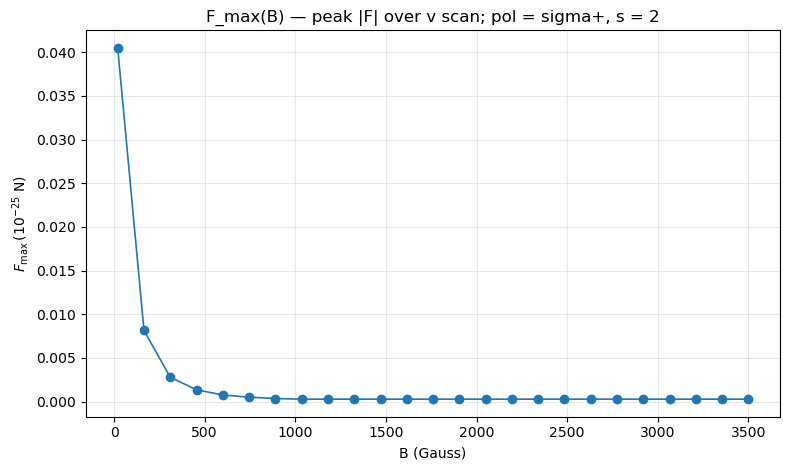

peak F_max @ B (G): 20.0 ,  v_at_max: 170.0  m/s


In [18]:
# F_max(B): peak |F| over v at each B
def F_max_vs_B(TM, B_list_G, v_min=-300, v_max=300, n_v=181,
               polarization='sigma+', s_per_p=2.0, detuning_MHz=0.0):
    v_arr = np.linspace(v_min, v_max, n_v)
    F_max = []
    v_at_max = []
    for B in B_list_G:
        F_arr = np.array([steady_state_rate_eq(
            TM, B, v, polarization=polarization, s_per_p=s_per_p,
            detuning_MHz=detuning_MHz)['F'] for v in v_arr])
        idx = int(np.argmax(np.abs(F_arr)))
        F_max.append(np.abs(F_arr[idx]))
        v_at_max.append(v_arr[idx])
    return np.array(B_list_G), np.array(F_max), np.array(v_at_max)

B_scan = np.linspace(20, 3500, 25)
B_arr, Fm, v_at = F_max_vs_B(TM, B_scan, polarization='sigma+', s_per_p=2.0)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(B_arr, Fm*1e25, '-o', lw=1.2)
ax.set_xlabel('B (Gauss)'); ax.set_ylabel(r'$F_\mathrm{max}\,(10^{-25}$ N)')
ax.set_title('F_max(B) — peak |F| over v scan; pol = sigma+, s = 2')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print('peak F_max @ B (G):', B_arr[np.argmax(Fm)],
      ',  v_at_max:', v_at[np.argmax(Fm)], ' m/s')

## Notes & next steps

**Sanity checks built in.**
- `compute_transitions_vs_B`-style normalization to max coupling at lowest sampled B (~ case-(b) stretched ME; approximate since A^2Pi_{1/2} is case-(a)/aBJ).
- BR closure (`leakage = 1 − Σ BR_subspace`) is the cross-check the existing `RaF_Zeeman_Slower.ipynb` validated.
- Rate-eq solution: `Σ N = 1` enforced and printed.

**Knobs to sweep next**
- Multi-frequency lasers (sidebands at fixed offsets).
- Multiple beam polarizations (e.g. σ⁺ + σ⁻ remixing for dark-state lifting).
- Replacing the linearized `B(z)` with cubic spline + root-find on `ν_ij(B)`.
- Toggling between `parity_e='+'` and `parity_e='-'` Λ-doublet components.

**Verification** — root CLAUDE.md gate (`jupyter execute RaF_Calcs_Tutorial.ipynb`) only applies to `Source Code/` changes; this is a notebook-only addition. To verify *this* notebook, restart kernel and Run All. Plots are gated to render only after the data step they depend on.
